## Capstone 2 Python


### This project analyzes sales data for the fictional company EmporiUm using Python, Pandas, NumPy, and Matplotlib within a Jupyter Notebook environment. 
### My assigned territories for this analysis are Colorado in the western region and South Carolina in southern region. I will compare sales performance, customer activity, store rankings, product trends, and monthly revenue to identify business insights and marketing opportunities. 
### The project also includes data cleaning, data visualization, and business recommendations supported by charts, along with a final presentation and video walkthrough of the analysis.

### Importing Python Libraries

In [1]:

# Down below I have imported and assigned an alias to three Python Libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as mp

### Creating a Class and Importing Datasets 


In [2]:
# I chose to use a class for this project because the analysis involves multiple related datasets, and a class helps keep all of the data, functions, and analysis organized in one structured project object. 
# Using a class also makes the code cleaner, easier to manage, and more scalable as I continue adding data cleaning, visualizations, and business analysis throughout the capstone project.
# def creates the function
# functions in a class are called methods
# __init__ is a special function that automatically runs when an object is created from a class.
# Also known as the construcotr method
# self is a temporary parameter that is references an object
# self.storesales is an attribute
# attributes hold values than can be used in objects 
# attributes are similar to variables
# pd.read_csv() allows me to import csv data into python using the pandas library
# Im storing the csv data in an attriubute to be used by an object later
# Windows files are saved as a single backslash but python only reads forward and double back slashes 
# You have to manually change the single backslashes to single forward slashes or double backslashes
# Created a second method that previews data the first 5 rows from each dataframe 
# A dataframe is a table made up of rows and columns in python
# Created a Thrid Method that shows dataframe(table) information
# () at the end of the method runs the method
# I then created a object then called both both methods using .methodname()  


class EmpAnalysis:

    def __init__(self): 
        self.storesales = pd.read_csv("C:\\Users\\User\\Documents\\Capstone_2\\StoreSales.csv")
        self.storedetails = pd.read_csv("C:\\Users\\User\\Documents\\Capstone_2\\StoreDetail.csv")
        self.products = pd.read_csv("C:\\Users\\User\\Documents\\Capstone_2\\Products.csv")
        self.productcategories = pd.read_csv("C:\\Users\\User\\Documents\\Capstone_2\\ProductCategories.csv")
        self.customer_list = pd.read_csv("C:\\Users\\User\\Documents\\Capstone_2\\customer_list.csv")

    
    def preview_data(self):
        
        print("\nCustomers List ")
        print(self.customer_list.head())

        print("\nProduct Categories ")
        print(self.productcategories.head())

        print("\nProducts")
        print(self.products.head())

        print("\nStore Details")
        print(self.storedetails.head())

        print("\nStores Sales")
        print(self.storesales.head())

    def tableinfo(self):
        
        print("\nCustomers Info ")
        self.customer_list.info()

        print("\nProduct Categories Info ")
        self.productcategories.info()

        print("\nProducts Info")
        self.products.info()

        print("\nStore Details Info")
        self.storedetails.info()

        print("\nStores Sales Info")
        self.storesales.info()

data_info = EmpAnalysis()

data_info.preview_data()
data_info.tableinfo()
        
    
    
    
    



Customers List 
     cust_id|date|time|name|email|phone|sms-opt-out 
0  1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1  2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2  3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3  4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4  5|2023-11-18|14:22:10|Joey|howyoudoing@central...

Product Categories 
   CategoryID                  Category SubcategoryID           Subcategory
0         120  Technology & Accessories       120-tab               Tablets
1         120  Technology & Accessories       120-cal           Calculators
2         120  Technology & Accessories       120-sof     Software Download
3         120  Technology & Accessories       120-hea            Headphones
4         120  Technology & Accessories       120-ext  External Accessories

Products
    Prod Num                        Product  CategoryID SubcategoryID
0  105248-IT               TCL NXTPAPER 10s         120       120-tab
1  105249-IT  Dell Latitude 7320 Detac

### Core Marketing Analysis

#### Question 1: 
##### Who are the territory managers for the sales territories assigned? What are the store IDs and cities 
##### for the stores in each assigned sales territory?

#### Step 1 
##### Identify the dataframe(table) your going to filter data from.

In [3]:
# Using an object created from the class we can see a preview of the first 5 rows in each dataframe(table) I imported using pandas
# I then can identify which tables are needed to answer this question.
# I've identified that I need to use the Store details dataframe(table).
# It has the 6 columns that include Store Location,State,Store ID,Territory Manager,Region ,Region Director
# After finding the table I need to create a new method in the class created earlier 
# If I created a a method outside of the codeblock the class is in, I want be able to use the previuos methods
# But for the sake of this project I'll do both since it is required 

data_info.preview_data()


Customers List 
     cust_id|date|time|name|email|phone|sms-opt-out 
0  1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1  2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2  3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3  4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4  5|2023-11-18|14:22:10|Joey|howyoudoing@central...

Product Categories 
   CategoryID                  Category SubcategoryID           Subcategory
0         120  Technology & Accessories       120-tab               Tablets
1         120  Technology & Accessories       120-cal           Calculators
2         120  Technology & Accessories       120-sof     Software Download
3         120  Technology & Accessories       120-hea            Headphones
4         120  Technology & Accessories       120-ext  External Accessories

Products
    Prod Num                        Product  CategoryID SubcategoryID
0  105248-IT               TCL NXTPAPER 10s         120       120-tab
1  105249-IT  Dell Latitude 7320 Detac

#### Step 2
##### Create a new method that filters columns.

In [4]:
# _____________________  Notes  _______________________________________________________________________

# Create a new method
# Assign a variable to the code that filters state by Colorado and South Carolina
# When you assign a variable to values the values are stored in the variable
# For this code to be accessed again with ease its needs to be stored as an attribute 
# or I'll have to rewite the code evry time
# self is a temporary parameter in the method that can be placeholder for object
# Im assigning the function to the code using =
# The code selects the state column and and matches it the the value Colorado and South Carolina
# | means or in python
# the code reads select all rows that have Colorado or South Carolina in the State column

# Filtering Columns
# Create another attribute 
# assign the attribute to to the previous attribute
# filter the previuos attribute for " Store Location","State","Store ID","Territory Manager"
# now the attribute only holds values that are in these 4 columns
# adding the method to to the class
# Python treats every codeblock in jupyter as a stand alone codeblock 
# so new mehtods that you create are not created on the class which makes them functions 
# you have to manually add them to the class
# you do this by assigning the function to the class like an attribute to a object
# add the print statement in the method so you dont have to add it later outside the method
# Once done you can assign it to a object 
# Then call the method 
# Using a for loop to print results
# Allows you to iterate through each index(number placement for row in table) 
# x allows you to iterate through values in the row
# x{state} means locate the value in this row under the state column
# These are done using the itterows() dataframe method in python
# The f strings allows you to add comments and varaibles to a print statement

# ______________________________________________________________________________________________________________

# Filter Territories

def filtered_territory_analysis(self):
    
    self.filtered_territory_data = self.storedetails[
        (self.storedetails["State"] == "Colorado") |
        (self.storedetails["State"] == "South Carolina") ]

# filter Columns
    
    self.filtered_territory_columns = self.filtered_territory_data[
        ["Store Location","State","Store ID","Territory Manager"]]

    
# Printing Results 
    print(self.filtered_territory_columns)
    print("\n── Assigned Territory Analysis ─────────────────────────")

    for index, x in self.filtered_territory_columns.iterrows():

        print(
            f"\nStore Record #{index}"
            f"\nState: {x['State']}"
            f"\nTerritory Manager: {x['Territory Manager']}"
            f"\nStore ID: {x['Store ID']}"
            f"\nCity: {x['Store Location']}"
        )
# Assigning Function to class

EmpAnalysis.filtered_territory_analysis = filtered_territory_analysis

# Use previuos object or make a new one

data_info.filtered_territory_analysis()



    



    Store Location           State  Store ID Territory Manager
0           Aurora        Colorado       701          Jim Heck
1         Berthoud        Colorado       702          Jim Heck
2          Boulder        Colorado       703          Jim Heck
3      Castle Rock        Colorado       704          Jim Heck
4           Denver        Colorado       705          Jim Heck
5        Englewood        Colorado       706          Jim Heck
6     Fort Collins        Colorado       707          Jim Heck
7   Grand Junction        Colorado       708          Jim Heck
8          Greeley        Colorado       709          Jim Heck
9        Lafayette        Colorado       710          Jim Heck
10       Littleton        Colorado       711          Jim Heck
11        Loveland        Colorado       712          Jim Heck
12        Milliken        Colorado       713          Jim Heck
13      New Castle        Colorado       714          Jim Heck
14          Parker        Colorado       715          J


#### Territory Analysis Summary

The analysis identified all stores located within the assigned sales territories of Colorado and South Carolina. Colorado stores are managed by Jim Heck, while South Carolina stores are managed by Len Jensen.

The filtered dataframe displayed the territory manager, store ID, and city location for each assigned store. A total of 18 stores were identified in Colorado and 2 stores were identified in South Carolina.

#### Question 2
##### What is monthly total revenue for in-store sales in each of the two sales territories, over the full 
##### period covered by the data? 

#### Step 1 Identify what tables are needed to answer this question.

In [5]:
# use tableinfo to find information about tables

data_info.tableinfo()


Customers Info 
<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    str  
dtypes: str(1)
memory usage: 4.2 KB

Product Categories Info 
<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB

Products Info
<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num      

#### Step 2
##### Merge Dataframes(tables), Modify Dataframe, Filter by Territories

In [6]:
#________ Notes ________________________________________________________________________________________________

# continue by creating mehthods associated with the EmpAnalysis class 
# identify the tables needed for for question
# Join tables using pd.merge from pandas
# using the object data_info.tableinfo() created earlier I can find the the data type and name of column
# In python, you need the same name and data type to join tables 
# The two tables Im going to use are storedetails and storesales
# to merge dataframes you need to store them in a variable or a attribute( I used an attribute)
# Next the column stored in the attribute needs to be converted to the datetime data type using pd.to_datetime
# Then the attribute can be retrieve the month name using dt.month_name()
# Then the attribute can be retrieve the Year using dt.year
# This creates two new columns Month and Year 
# Group By month, year and state columns using the .groupby datarame method then find the sum sales of each group
# When using a dataframe method you dont have to specify the library your calling the method/function from
# now add this method to the class 


#_______________________________________________________________________________________________________________

def east_south_monthly_revenue(self):

# Merging dataframes(tables) using an attribute 
    
    self.table_merge = pd.merge(
        self.storedetails,
        self.storesales,
        on = "Store ID")
    
# Convert Transaction Date column to datetime
    
    self.table_merge["Transaction Date"] = pd.to_datetime(
        self.table_merge["Transaction Date"])

# Create Month and Year column from Transaction Date
    
    self.table_merge["Month"] = self.table_merge[
        "Transaction Date"].dt.month_name()
 
    self.table_merge["Year"] = self.table_merge[
        "Transaction Date"].dt.year
    
# Filtering Territories
    
    self.filter_merge = self.table_merge[
        (self.table_merge["State"] == "South Carolina") |
        (self.table_merge["State"] == "Colorado") ]

# Grouping By Month,State,and Year 

    self.grouped_merge = self.filter_merge.groupby(
        ["Year","Month","State"])["Sale Amount"].sum()

# Printing outputs

    print("\n── Monthly Territory Revenue Analysis For Each Year ─────────────────")

    for (Year, Month, State), revenue in self.grouped_merge.items():

        print(
            f"\nYear: {Year}"
            f"\nMonth: {Month}"
            f"\nTerritory: {State}"
        f"\nTotal Revenue: ${revenue:,.2f}")

# Assigning Function to class

EmpAnalysis.east_south_monthly_revenue = east_south_monthly_revenue

# Use previuos object or make a new one

data_info.east_south_monthly_revenue()


── Monthly Territory Revenue Analysis For Each Year ─────────────────

Year: 2022
Month: April
Territory: Colorado
Total Revenue: $89,350.31

Year: 2022
Month: April
Territory: South Carolina
Total Revenue: $8,929.63

Year: 2022
Month: August
Territory: Colorado
Total Revenue: $87,058.36

Year: 2022
Month: August
Territory: South Carolina
Total Revenue: $8,916.43

Year: 2022
Month: December
Territory: Colorado
Total Revenue: $78,541.63

Year: 2022
Month: December
Territory: South Carolina
Total Revenue: $8,360.87

Year: 2022
Month: February
Territory: Colorado
Total Revenue: $80,315.69

Year: 2022
Month: February
Territory: South Carolina
Total Revenue: $9,763.98

Year: 2022
Month: January
Territory: Colorado
Total Revenue: $77,950.98

Year: 2022
Month: January
Territory: South Carolina
Total Revenue: $9,640.38

Year: 2022
Month: July
Territory: Colorado
Total Revenue: $94,048.49

Year: 2022
Month: July
Territory: South Carolina
Total Revenue: $13,083.78

Year: 2022
Month: June
Territ

#### Monthly Territory Analysis By Year 
The revenue analysis shows that Colorado consistently generated significantly higher sales revenue than South Carolina from 2022–2025, making it the company’s strongest-performing territory. 

Both territories experienced steady year-over-year growth, with the highest sales occurring during 2025, indicating expanding business performance and increasing customer demand.

#### Question 3 
##### How would you rank the sales performance of each store in each sales territory? Which are the 
##### top-performing stores? 

#### Step 1 Identify tables needed to answer the question.

In [7]:
# use tableinfo to find information about tables

data_info.tableinfo()


Customers Info 
<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    str  
dtypes: str(1)
memory usage: 4.2 KB

Product Categories Info 
<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB

Products Info
<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num      

### Step 2 Merge Dataframes(tables), Modify Dataframe, Filter by Territories, Rank Outputs from Greatest to Least

In [8]:
#________ Notes _________________________________________________________________________________________

# Tables needed to answer the question are storedetails and storesales
# Just like before 
# Im going to resuse code I already scripted for the sake of time
# Merge dataframes storedetails and storesales using pd.merge
# Filter for rows that have colorado or south carolina in the state column using []
# group by by the state, store id and the store location column
# sort from best performing to the least performing using the sort values dataframe method
# the default for sort values is least to greatest so you have to make the argument false to reverse the order
# ascending = false
# When ranking the stores by highest grossing you need to use the enumerate function 
# This ranks return values in the for loop
# loop reads as follows: for every loop return state, state id, city, revenue, and store rank 
# Then print values using an f string that includes a new line(\n) for each value 
# Then assign the method to the class
# Then call the method using an object


#___________________________________________________________________________________________________________

def store_sales_ranking_east_south_region(self):

# Merge dataframes
    
    self.table_merge = pd.merge(
        self.storedetails,
        self.storesales,
        on="Store ID")

# Filter assigned territories
    
    self.filter_merge = self.table_merge[
        (self.table_merge["State"] == "Colorado") |
        (self.table_merge["State"] == "South Carolina")]

# Group by Store, Location, and State
    
    self.grouped_merge = self.filter_merge.groupby(
        ["State", "Store ID", "Store Location"]
    )["Sale Amount"].sum()

# Sort from greatest to least
    
    self.sorted_merge = self.grouped_merge.sort_values(
        ascending=False)

    print("\n── Store Sales Performance Ranking ─────────────────────")

# Rank stores
    
    for rank, ((state, store_id, city), revenue) in enumerate(
        self.sorted_merge.items(),
        start=1):

        print(
            f"\nRank #{rank}"
            f"\nTerritory: {state}"
            f"\nStore ID: {store_id}"
            f"\nCity: {city}"
            f"\nTotal Revenue: ${revenue:,.2f}")


# Assign method to class

EmpAnalysis.store_sales_ranking_east_south_region = store_sales_ranking_east_south_region

# Run analysis

data_info.store_sales_ranking_east_south_region()


── Store Sales Performance Ranking ─────────────────────

Rank #1
Territory: Colorado
Store ID: 705
City: Denver
Total Revenue: $917,471.53

Rank #2
Territory: Colorado
Store ID: 709
City: Greeley
Total Revenue: $640,368.11

Rank #3
Territory: Colorado
Store ID: 706
City: Englewood
Total Revenue: $344,647.48

Rank #4
Territory: Colorado
Store ID: 710
City: Lafayette
Total Revenue: $337,169.61

Rank #5
Territory: South Carolina
Store ID: 853
City: Greenville
Total Revenue: $337,002.00

Rank #6
Territory: Colorado
Store ID: 703
City: Boulder
Total Revenue: $321,197.88

Rank #7
Territory: Colorado
Store ID: 716
City: Sedalia
Total Revenue: $319,776.13

Rank #8
Territory: Colorado
Store ID: 701
City: Aurora
Total Revenue: $317,198.67

Rank #9
Territory: South Carolina
Store ID: 852
City: Charleston
Total Revenue: $311,810.56

Rank #10
Territory: Colorado
Store ID: 708
City: Grand Junction
Total Revenue: $306,834.49

Rank #11
Territory: Colorado
Store ID: 707
City: Fort Collins
Total Reven

#### Ranking Summary
Colorado was the strongest overall sales territory, accounting for 18 of the top 20 ranked stores in total revenue performance. Store 705 in Denver was the highest-performing location, generating more than 917,000 in total revenue during the reporting period. 

The lowest-performing store in the rankings was Store 715 in Parker, Colorado, with approximately 279,000 in total revenue.

### Question 4
#### Comparing the customer ID from the customer list data with the rewards ID from the sales data, 
#### who were the top customers in each sales territory? 

### Step 1 Identify tables needed

In [9]:
# use tableinfo to find information about tables

data_info.tableinfo()


Customers Info 
<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    str  
dtypes: str(1)
memory usage: 4.2 KB

Product Categories Info 
<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB

Products Info
<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num      

#### Step 2  Merge Dataframes(tables), Modify Dataframe, Filter by Territories, Rank Customers

In [10]:
#________ Notes ________________________________________________________________________________________________

# The customer_list file was imported incorrectly as one column.
# The customer_list file uses "|" instead of commas as the delimiter.
# Split the single column into multiple columns using .str.split().
# Rename the separated columns.
# Convert cust_id and RewardsID into float data types.
# Merge storesales and customer_list using RewardsID and cust_id.
# Merge customer_sales_merge with storedetails using Store ID.
# Group the data by State, cust_id, and name.
# Use .sum() to calculate the total sales revenue for each customer.
# Sort the grouped data from highest to lowest using .sort_values().
# Convert the grouped results into a dataframe using .reset_index().
# Use .head(5) to display the top 5 customers in each territory.
# Use enumerate() and .itertuples() to print formatted results.

#_______________________________________________________________________________________________________________



def top_customers_by_territory(self):

    
# Split customer_list only if needed
    

    if len(self.customer_list.columns) == 1:

        self.customer_list = self.customer_list[
            self.customer_list.columns[0]
        ].str.split("|", expand=True)
        
# Rename columns
        

        self.customer_list.columns = [
            "cust_id",
            "date",
            "time",
            "name",
            "email",
            "phone",
            "sms_opt_out"]

    
# Convert IDs to same datatype
    

    self.customer_list["cust_id"] = (
        self.customer_list["cust_id"].astype(float))

    self.storesales["RewardsID"] = (
        self.storesales["RewardsID"].astype(float))

    
# Merge customer list with sales data
    

    self.customer_sales_merge = pd.merge(
        self.storesales,
        self.customer_list,
        left_on="RewardsID",
        right_on="cust_id",
        how="inner")

    
# Merge with store details
    

    self.customer_territory_merge = pd.merge(
        self.customer_sales_merge,
        self.storedetails,
        on="Store ID",
        how="inner")

    
# Group by territory and customer


    self.top_customers = self.customer_territory_merge.groupby(
        ["State", "cust_id", "name"]
    )["Sale Amount"].sum()

   
# Sort highest revenue customers first
    

    self.sorted_top_customers = self.top_customers.sort_values(
        ascending=False)

    
# Convert grouped results into dataframe
    

    self.top_customers_df = (
        self.sorted_top_customers.reset_index())

    
# Print top 5 customers by territory
    

    print("\n── Top 5 Customers by Sales Territory ───────────────\n")

    for territory in ["Colorado", "South Carolina"]:

        print(f"\n========== {territory} ==========\n")

        self.territory_top5 = self.top_customers_df[
            self.top_customers_df["State"] == territory
        ].head(5)

        for rank, row in enumerate(
            self.territory_top5.itertuples(),
            start=1):

            print(f"""
                Rank #{rank}

                Territory: {row.State}

                Customer ID: {row.cust_id}

                Customer Name: {row.name}

                Total Revenue: ${row._4:,.2f}""")



# Add Method to Class


EmpAnalysis.top_customers_by_territory = top_customers_by_territory



# Run Method


data_info.top_customers_by_territory()


── Top 5 Customers by Sales Territory ───────────────


========== Colorado ==========


Rank #1

Territory: Colorado

Customer ID: 245.0

Customer Name: Gloria Mendoza

Total Revenue: $7,855.66


Rank #2

Territory: Colorado

Customer ID: 375.0

Customer Name: C.J. Cregg

Total Revenue: $5,006.57


Rank #3

Territory: Colorado

Customer ID: 380.0

Customer Name: Abbey Bartlet

Total Revenue: $4,605.19


Rank #4

Territory: Colorado

Customer ID: 242.0

Customer Name: Lorna Morello

Total Revenue: $4,381.15


Rank #5

Territory: Colorado

Customer ID: 279.0

Customer Name: Adrian Veidt

Total Revenue: $4,365.77


========== South Carolina ==========


Rank #1

Territory: South Carolina

Customer ID: 340.0

Customer Name: Jin Kwon

Total Revenue: $1,786.05


Rank #2

Territory: South Carolina

Customer ID: 404.0

Customer Name: Roman Roy

Total Revenue: $1,778.84


Rank #3

Territory: South Carolina

Customer ID: 213.0

Customer Name: Jazz

Total Revenue: $1,763.70


Rank #4

Territory

#### Top Customer Per Territory Summary
Colorado was the strongest-performing territory overall, with Gloria Mendoza generating the highest customer revenue at approximately 7,855.66, while Adrian Veidt was the lowest-ranked top-five customer in the territory with about 4,365.77 in sales. 

In South Carolina, Jin Kwon was the highest-performing customer with approximately 1,786.05 in revenue, while Cal Abar ranked lowest among the top five customers with about 1,396.50 in sales. Overall, Colorado significantly outperformed South Carolina in total customer revenue, indicating a stronger concentration of high-value customers within the territory.

### Top Customer Sales Chart

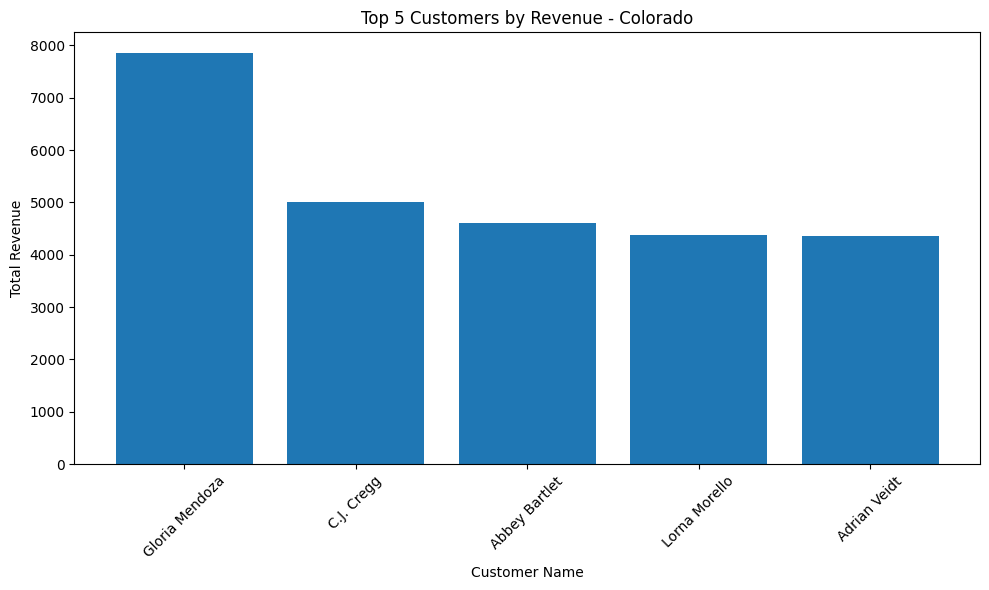

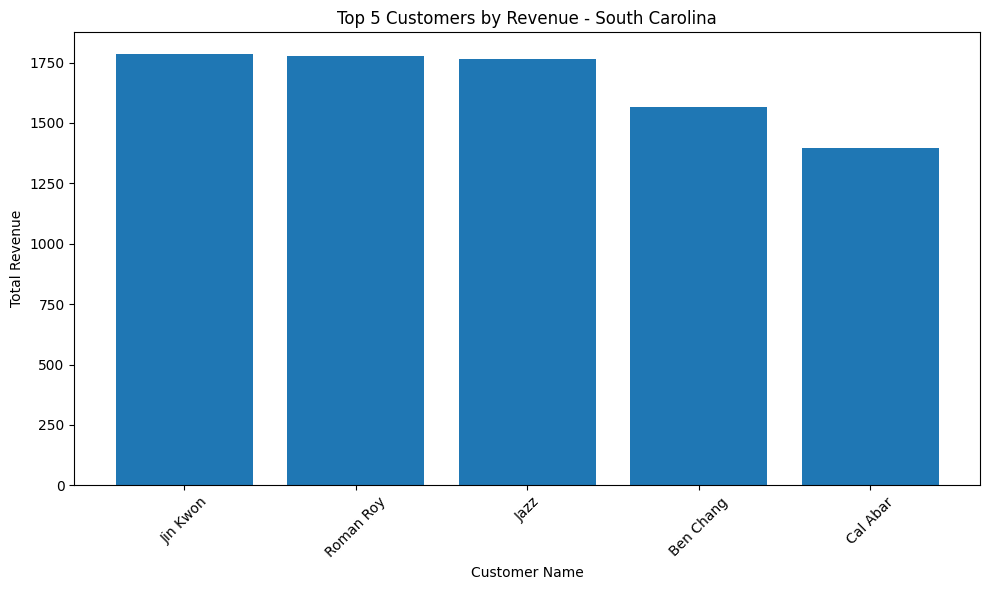

In [11]:
#________ Chart Notes ___________________________________________________________________________________________

# Import matplotlib.pyplot as plt to create charts and visualizations.
# Use a for loop to create separate charts for Colorado and South Carolina.
# Filter the dataframe by State so each chart only displays one territory.
# Use plt.bar() to create a bar chart for customer revenue.
# The x-axis displays customer names.
# The y-axis displays total revenue generated by each customer.
# figsize controls the size of the chart window.
# plt.title(), plt.xlabel(), and plt.ylabel() add chart labels.
# plt.xticks(rotation=45) rotates customer names for easier reading.
# plt.tight_layout() prevents labels from overlapping.
# plt.show() displays the completed chart.

#_______________________________________________________________________________________________________________


#________ Results Notes _________________________________________________________________________________________

# The charts display the top 5 customers with the highest
# total sales revenue in Colorado and South Carolina.

# Colorado customers generated significantly higher revenue
# totals compared to South Carolina customers, indicating
# stronger customer spending within the Colorado territory.

# Gloria Mendoza was the highest-performing customer overall,
# generating more than $7,800 in total revenue for Colorado.

# The Colorado territory showed a larger gap between the
# highest-performing and lowest-performing top customers,
# suggesting a stronger concentration of high-value customers.

# South Carolina generated lower customer revenue totals,
# but the top customers still contributed consistently to
# territory sales performance.

# The charts help identify the company’s most valuable
# customers and may support future customer retention,
# loyalty programs, and targeted marketing strategies.

# Customers with consistently high purchase activity may
# represent long-term business opportunities and priority
# customer relationships.

#_______________________________________________________________________________________________________________




# Create chart for each territory

for territory in ["Colorado", "South Carolina"]:

    # Filter territory data

    territory_chart = data_info.top_customers_df[
        data_info.top_customers_df["State"] == territory
    ].head(5)


    # Create bar chart

    mp.figure(figsize=(10, 6))

    mp.bar(
        territory_chart["name"],
        territory_chart["Sale Amount"]
    )


    # Chart labels

    mp.title(
        f"Top 5 Customers by Revenue - {territory}"
    )

    mp.xlabel("Customer Name")

    mp.ylabel("Total Revenue")

    mp.xticks(rotation=45)

    mp.tight_layout()

    mp.show()

### Question 5 
#### What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category?   What might this tell you about the most  popular products, and where could there be opportunity for growth? 

#### Step 1 Identify what tables are needed to answer this question.

In [12]:
# use tableinfo to find information about tables

data_info.tableinfo()


Customers Info 
<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cust_id      521 non-null    float64
 1   date         521 non-null    str    
 2   time         521 non-null    str    
 3   name         521 non-null    str    
 4   email        521 non-null    str    
 5   phone        520 non-null    str    
 6   sms_opt_out  520 non-null    str    
dtypes: float64(1), str(6)
memory usage: 28.6 KB

Product Categories Info 
<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB

Products Info
<class 'pandas.DataFrame'>
RangeI

In [13]:
#________ Notes ________________________________________________________________________________________________

# The tables used for this analysis are storesales, products,
# productcategories, and storedetails.
# storesales contains transaction dates, product numbers, and sale amounts.
# products contains the product names and category IDs.
# productcategories contains category and subcategory information.
# storedetails contains territory and store information.
# Convert Transaction Date into datetime format using pd.to_datetime().
# Extract the Month and Year using dt.month_name() and dt.year.
# Merge storesales and products using Prod Num.
# Merge products and productcategories using CategoryID and SubcategoryID.
# Merge the combined dataframe with storedetails using Store ID.
# Filter the data for Colorado and South Carolina territories only.
# Group the data by Year, Month, State, and Category.
# Use .count() to calculate the number of transactions per category.
# Use .sum() to calculate total sales revenue by category.
# Sort the grouped data using .sort_index().
# Print formatted transaction and revenue results using for loops.

#_______________________________________________________________________________________________________________






def monthly_category_analysis(self):

   
# Convert Transaction Date to datetime
    

    self.storesales["Transaction Date"] = pd.to_datetime(
        self.storesales["Transaction Date"])

    
# Create Month and Year columns
    

    self.storesales["Month"] = (
        self.storesales["Transaction Date"].dt.month_name())

    self.storesales["Year"] = (
        self.storesales["Transaction Date"].dt.year)

    
# Merge storesales with products
    

    self.sales_products_merge = pd.merge(
        self.storesales,
        self.products,
        on="Prod Num",
        how="inner")

    
# Merge with productcategories
    

    self.sales_category_merge = pd.merge(
        self.sales_products_merge,
        self.productcategories,
        on=["CategoryID", "SubcategoryID"],
        how="inner")

    
# Merge with storedetails
    

    self.final_category_merge = pd.merge(
        self.sales_category_merge,
        self.storedetails,
        on="Store ID",
        how="inner")

    
# Filter assigned territories
    

    self.filtered_territories = self.final_category_merge[
        (self.final_category_merge["State"] == "Colorado") |
        (self.final_category_merge["State"] == "South Carolina")]

    
# Group transaction counts
    

    self.transaction_summary = self.filtered_territories.groupby(
        ["Year", "Month", "State", "Category"]
    )["Prod Num"].count()

    
# Group revenue totals
    

    self.revenue_summary = self.filtered_territories.groupby(
        ["Year", "Month", "State", "Category"]
    )["Sale Amount"].sum()

    
# Sort grouped data
    

    self.transaction_summary = (
        self.transaction_summary.sort_index())

    self.revenue_summary = (
        self.revenue_summary.sort_index())

    
# Print transaction results
    

    print("\n── Monthly Transactions by Product Category ───────────────\n")

    for (year, month, state, category), transactions in (
        self.transaction_summary.items()):

        print(f"""
            Year: {year}

            Month: {month}

            Territory: {state}

            Category: {category}

            Transactions: {transactions}""")

    
# Print revenue results
    

    print("\n── Monthly Revenue by Product Category ───────────────\n")

    for (year, month, state, category), revenue in (
        self.revenue_summary.items()):

        print(f"""
            Year: {year}

            Month: {month}

            Territory: {state}

            Category: {category}

            Total Revenue: ${revenue:,.2f}""")



# Add Method to Class


EmpAnalysis.monthly_category_analysis = monthly_category_analysis



# Run Method


data_info.monthly_category_analysis()


── Monthly Transactions by Product Category ───────────────


Year: 2022

Month: April

Territory: Colorado

Category: Apparel and Merchandise

Transactions: 100


Year: 2022

Month: April

Territory: Colorado

Category: Art Supplies

Transactions: 77


Year: 2022

Month: April

Territory: Colorado

Category: Books (General)

Transactions: 42


Year: 2022

Month: April

Territory: Colorado

Category: Stationery and Supplies

Transactions: 113


Year: 2022

Month: April

Territory: Colorado

Category: Technology & Accessories

Transactions: 136


Year: 2022

Month: April

Territory: Colorado

Category: Textbooks

Transactions: 112


Year: 2022

Month: April

Territory: South Carolina

Category: Apparel and Merchandise

Transactions: 9


Year: 2022

Month: April

Territory: South Carolina

Category: Art Supplies

Transactions: 9


Year: 2022

Month: April

Territory: South Carolina

Category: Books (General)

Transactions: 4


Year: 2022

Month: April

Territory: South Carolina

Categor

### Business Summary

The monthly category analysis helps identify which product categories generate the highest transaction volume and sales revenue within the Colorado and South Carolina territories. Categories with consistently high transaction counts and strong monthly revenue likely represent the company’s most popular products and strongest-performing merchandise segments.

Colorado is expected to generate significantly higher transaction volume and revenue because it consistently outperformed South Carolina in previous territory sales analyses. Product categories with lower transaction counts or weaker sales revenue may present opportunities for growth through additional marketing campaigns, inventory expansion, product promotions, or improved store placement strategies.

Seasonal sales trends may also reveal months where certain product categories become more popular, helping management make better decisions related to forecasting, inventory management, and future business planning.

### Monthly Transactions and Revenue by Product Category Chart

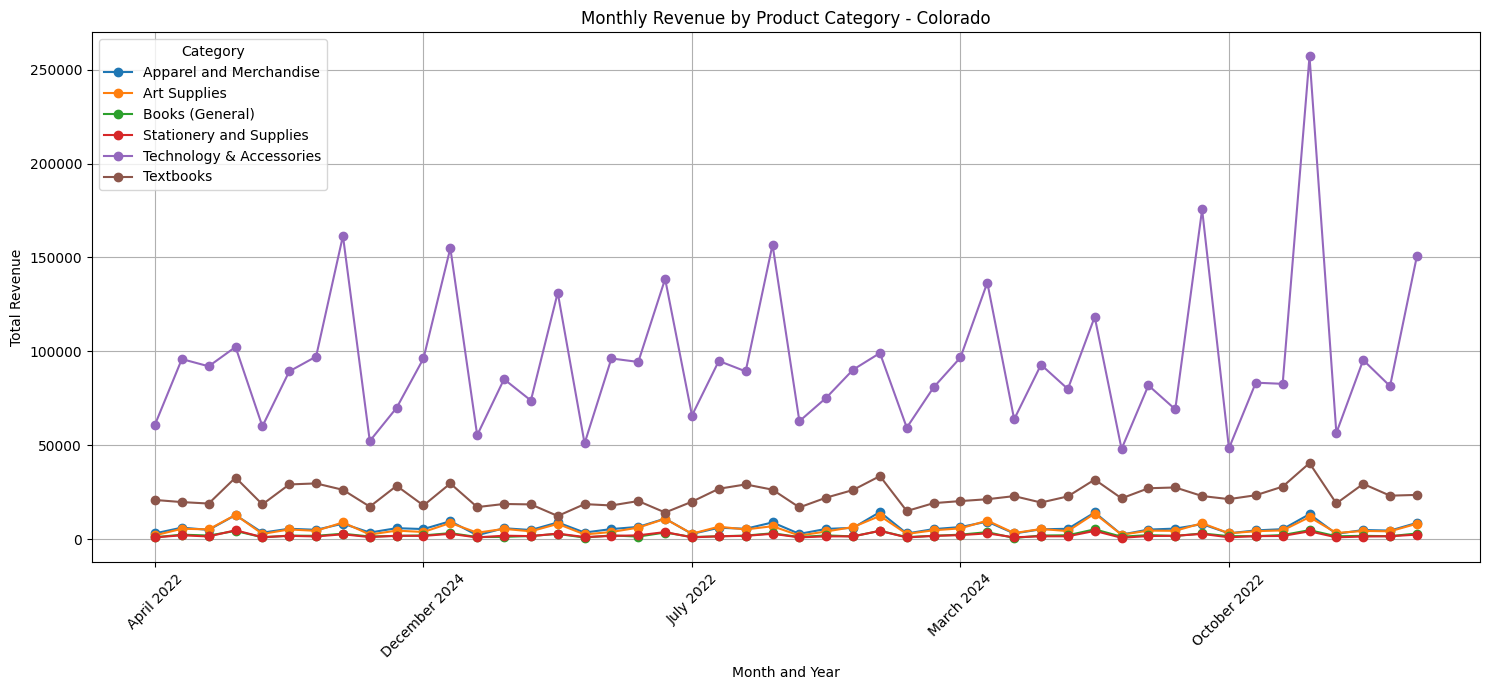

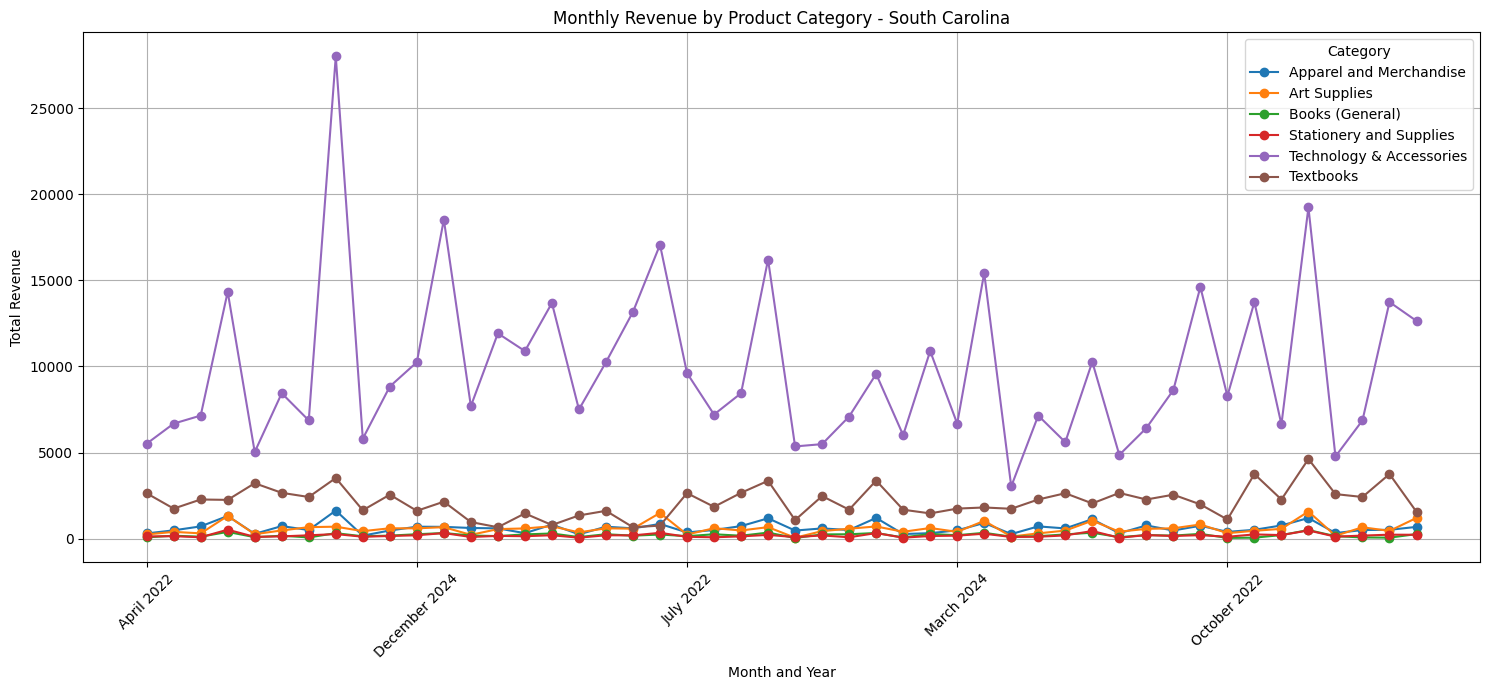

In [14]:
#________ Chart Notes ___________________________________________________________________________________________

# Import matplotlib.pyplot as plt to create charts and visualizations.
# Convert revenue_summary into a dataframe using .reset_index().
# .reset_index() converts the grouped index values into regular columns.
# Create a new Month_Year column by combining Month and Year columns together.
# This improves readability on the x-axis of the chart.
# Use a for loop to create a separate chart for Colorado and South Carolina.
# Filter the dataframe by State so each chart only displays one territory.
# Use .pivot_table() to reorganize the dataframe for plotting.
# The index becomes Month_Year for the x-axis values.
# The columns become product categories so each category becomes its own line.
# The values parameter uses Sale Amount to plot total revenue.
# Use .plot(kind="line") to create a line chart.
# marker="o" places dots on each data point.
# figsize controls the size of the chart window.
# plt.title(), plt.xlabel(), and plt.ylabel() add chart labels.
# plt.xticks(rotation=45) rotates labels for easier reading.
# plt.grid(True) adds grid lines to improve readability.
# plt.tight_layout() prevents labels from overlapping.
# plt.show() displays the completed chart.

#_______________________________________________________________________________________________________________

#________ Results Notes _________________________________________________________________________________________

# The charts display the monthly sales revenue generated by
# each product category within the Colorado and South Carolina territories.

# Colorado consistently shows higher revenue totals across
# most product categories, indicating stronger overall sales
# performance compared to South Carolina.

# Product categories with the highest and most consistent
# revenue lines likely represent the company’s most popular
# and profitable products.

# Large spikes in revenue during certain months may indicate
# seasonal purchasing trends or successful promotional periods.

# Categories with lower or inconsistent revenue may represent
# opportunities for future business growth through marketing,
# product expansion, or inventory adjustments.

# Comparing category performance between territories can help
# identify which products perform better in specific markets.

# The charts also help management visualize long-term sales
# trends and make data-driven decisions related to forecasting,
# budgeting, and inventory planning.

# If one category consistently outperforms others in both
# territories, it may deserve additional investment and
# promotional support.

# Categories with declining revenue trends may require further
# investigation to determine whether customer demand is changing.

#_______________________________________________________________________________________________________________
revenue_chart = (
    data_info.revenue_summary.reset_index())

# -------------------------------------------------
# Create combined Month-Year column
# -------------------------------------------------

revenue_chart["Month_Year"] = (
    revenue_chart["Month"] + " " +
    revenue_chart["Year"].astype(str))


# Create chart for each territory

for territory in ["Colorado", "South Carolina"]:

    # Filter territory data

    territory_chart = revenue_chart[
        revenue_chart["State"] == territory
    ]


    # Pivot data for plotting

    chart_pivot = territory_chart.pivot_table(
        index="Month_Year",
        columns="Category",
        values="Sale Amount",
        aggfunc="sum"
    )


    # Create line chart

    chart_pivot.plot(
        kind="line",
        marker="o",
        figsize=(15, 7)
    )


    # Chart labels

    mp.title(
        f"Monthly Revenue by Product Category - {territory}"
    )

    mp.xlabel("Month and Year")

    mp.ylabel("Total Revenue")

    mp.xticks(rotation=45)

    mp.grid(True)

    mp.tight_layout()

    mp.show()

### What is your recommendation for where to focus marketing attention in the next quarter?


#### Business Recommendations
Based on the analysis, I recommend focusing marketing efforts on the Colorado territory because it consistently generated the highest sales revenue and contained most of the top-performing stores. Marketing campaigns should emphasize high demand categories such as Technology & Accessories, Stationery and Supplies, and Textbooks while also using targeted promotions to increase sales in lower-performing categories. Additionally, expanding loyalty and customer retention programs around the highest-spending customers could help drive future revenue growth across both territories.
